# EDA Evidence Pack (BraTS + IXI)

This notebook compares:
- BraTS: before vs after preprocessing
- IXI: before vs after preprocessing
- Cross-dataset: BraTS after vs IXI after

Drop `.npy` slices into: `data/eda_evidence/{brats_before, brats_after, ixi_before, ixi_after}` and run all cells.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from scipy import ndimage

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

def pick_existing(paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return paths[0] if len(paths) > 0 else None

# Switch this to False if you want to use only data/eda_evidence folders
USE_SOURCE_DATA = False

if IN_COLAB:
    ROOT = '/content/drive/MyDrive/symAD-ECNN/data/eda_evidence'
else:
    ROOT = r'c:\Users\rifad\symAD-ECNN\data\eda_evidence'

if USE_SOURCE_DATA:
    # BraTS local folders (before/after)
    brats_before_candidates = [
        r'c:\Users\rifad\symAD-ECNN\data\brats_test_with_masks_raw\images',
        r'c:\Users\rifad\symAD-ECNN\data\brats_t1\filtered'
    ]
    brats_after_candidates = [
        r'c:\Users\rifad\symAD-ECNN\data\brats_t1_with_masks_processed\images',
        r'c:\Users\rifad\symAD-ECNN\data\brats_t1\resized'
    ]

    # IXI in Drive (Google Drive Desktop or Colab mount)
    if IN_COLAB:
        ixi_before_candidates = [
            '/content/drive/MyDrive/symAD-ECNN/data/ixi_t1/ixi_skull_stripped',
            '/content/drive/MyDrive/symAD-ECNN/data/ixi_t1/raw_ixi'
        ]
        ixi_after_candidates = [
            '/content/drive/MyDrive/symAD-ECNN/data/ixi_t1/processed_ixi/train',
            '/content/drive/MyDrive/symAD-ECNN/data/ixi_t1/ixi_t1_slices_128'
        ]
    else:
        ixi_before_candidates = [
            r'G:\My Drive\symAD-ECNN\data\ixi_t1\ixi_skull_stripped',
            r'H:\My Drive\symAD-ECNN\data\ixi_t1\ixi_skull_stripped',
            r'G:\My Drive\symAD-ECNN\data\ixi_t1\raw_ixi'
        ]
        ixi_after_candidates = [
            r'G:\My Drive\symAD-ECNN\data\ixi_t1\processed_ixi\train',
            r'H:\My Drive\symAD-ECNN\data\ixi_t1\processed_ixi\train',
            r'G:\My Drive\symAD-ECNN\data\ixi_t1\ixi_t1_slices_128'
        ]

    BRA_TS_BEFORE = pick_existing(brats_before_candidates)
    BRA_TS_AFTER = pick_existing(brats_after_candidates)
    IXI_BEFORE = pick_existing(ixi_before_candidates)
    IXI_AFTER = pick_existing(ixi_after_candidates)
else:
    BRA_TS_BEFORE = os.path.join(ROOT, 'brats_before')
    BRA_TS_AFTER = os.path.join(ROOT, 'brats_after')
    IXI_BEFORE = os.path.join(ROOT, 'ixi_before')
    IXI_AFTER = os.path.join(ROOT, 'ixi_after')

OUT_DIR = os.path.join(ROOT, 'outputs')
os.makedirs(OUT_DIR, exist_ok=True)

print('Runtime:', 'colab' if IN_COLAB else 'local')
print('USE_SOURCE_DATA:', USE_SOURCE_DATA)
print('ROOT:', ROOT)
print('BraTS before:', BRA_TS_BEFORE, '->', os.path.exists(BRA_TS_BEFORE))
print('BraTS after :', BRA_TS_AFTER, '->', os.path.exists(BRA_TS_AFTER))
print('IXI before  :', IXI_BEFORE, '->', os.path.exists(IXI_BEFORE))
print('IXI after   :', IXI_AFTER, '->', os.path.exists(IXI_AFTER))
print('Outputs     :', OUT_DIR, '->', os.path.exists(OUT_DIR))

Runtime: colab
USE_SOURCE_DATA: False
ROOT: /content/drive/MyDrive/symAD-ECNN/data/eda_evidence
BraTS before: /content/drive/MyDrive/symAD-ECNN/data/eda_evidence/brats_before -> False
BraTS after : /content/drive/MyDrive/symAD-ECNN/data/eda_evidence/brats_after -> False
IXI before  : /content/drive/MyDrive/symAD-ECNN/data/eda_evidence/ixi_before -> False
IXI after   : /content/drive/MyDrive/symAD-ECNN/data/eda_evidence/ixi_after -> False
Outputs     : /content/drive/MyDrive/symAD-ECNN/data/eda_evidence/outputs -> True


In [24]:
def list_inputs(folder):
    # Accept both slice files (.npy) and raw MRI volumes (.nii/.nii.gz).
    npy_files = sorted(glob.glob(os.path.join(folder, '*.npy')))
    nii_files = sorted(glob.glob(os.path.join(folder, '*.nii')) + glob.glob(os.path.join(folder, '*.nii.gz')))
    return npy_files + nii_files

def load_slice(path):
    ext = os.path.splitext(path)[1].lower()
    if path.lower().endswith('.nii') or path.lower().endswith('.nii.gz'):
        vol = nib.load(path).get_fdata().astype(np.float32)
        # Use middle axial slice as a representative slice for EDA when raw 3D is provided.
        z = vol.shape[2] // 2
        arr = vol[:, :, z]
        vmin, vmax = float(arr.min()), float(arr.max())
        if vmax - vmin > 1e-6:
            arr = (arr - vmin) / (vmax - vmin)
        else:
            arr = np.zeros_like(arr, dtype=np.float32)
        return arr.astype(np.float32)
    arr = np.load(path)
    return arr.astype(np.float32)

def fg_mask(img, thr=0.05):
    return img > thr

def center_offset_px(img, thr=0.05):
    h, w = img.shape[:2]
    m = fg_mask(img, thr)
    if np.count_nonzero(m) < 30:
        return np.nan
    cy, cx = ndimage.center_of_mass(m)
    return float(np.sqrt((cy - h / 2.0) ** 2 + (cx - w / 2.0) ** 2))

def summarize_files(files, sample_n=1200, thr=0.05):
    if len(files) == 0:
        return None, None
    sampled = random.sample(files, min(sample_n, len(files)))
    rows = []
    fg_values = []
    for f in sampled:
        img = load_slice(f)
        m = fg_mask(img, thr)
        bg = img[~m]
        fg = img[m]
        if fg.size > 0:
            fg_values.append(fg)
        rows.append({
            'file': os.path.basename(f),
            'shape': tuple(img.shape),
            'mean_all': float(img.mean()),
            'std_all': float(img.std()),
            'fg_ratio': float(np.count_nonzero(m) / m.size),
            'bg_mean': float(bg.mean()) if bg.size > 0 else 0.0,
            'bg_std': float(bg.std()) if bg.size > 0 else 0.0,
            'center_offset_px': center_offset_px(img, thr)
        })
    df = pd.DataFrame(rows)
    fg_cat = np.concatenate(fg_values) if len(fg_values) > 0 else np.array([])
    return df, fg_cat

def safe_mean(df, col):
    if df is None or len(df) == 0:
        return np.nan
    return float(np.nanmean(df[col].values))

In [5]:
brats_before_files = list_inputs(BRA_TS_BEFORE)
brats_after_files = list_inputs(BRA_TS_AFTER)
ixi_before_files = list_inputs(IXI_BEFORE)
ixi_after_files = list_inputs(IXI_AFTER)

# print(f'BraTS before: {len(brats_before_files):,}')
# print(f'BraTS after:  {len(brats_after_files):,}')
# print(f'IXI before:   {len(ixi_before_files):,}')
# print(f'IXI after:    {len(ixi_after_files):,}')

## BraTS: Before vs After

In [ ]:
brats_before_df, brats_before_fg = summarize_files(brats_before_files)
brats_after_df, brats_after_fg = summarize_files(brats_after_files)

brats_results = pd.DataFrame([
    {'Metric': 'Global mean intensity', 'Before': safe_mean(brats_before_df, 'mean_all'), 'After': safe_mean(brats_after_df, 'mean_all')},
    {'Metric': 'Global std intensity', 'Before': safe_mean(brats_before_df, 'std_all'), 'After': safe_mean(brats_after_df, 'std_all')},
    {'Metric': 'Foreground ratio', 'Before': safe_mean(brats_before_df, 'fg_ratio'), 'After': safe_mean(brats_after_df, 'fg_ratio')},
    {'Metric': 'Background mean', 'Before': safe_mean(brats_before_df, 'bg_mean'), 'After': safe_mean(brats_after_df, 'bg_mean')},
    {'Metric': 'Background std', 'Before': safe_mean(brats_before_df, 'bg_std'), 'After': safe_mean(brats_after_df, 'bg_std')},
    {'Metric': 'Center offset (pixels)', 'Before': safe_mean(brats_before_df, 'center_offset_px'), 'After': safe_mean(brats_after_df, 'center_offset_px')}
])
brats_results['Delta (After-Before)'] = brats_results['After'] - brats_results['Before']
brats_results

,Metric,Before,After,Delta (After-Before)
0,Global mean intensity,0.155015,0.166123,0.011108
1,Global std intensity,0.280685,0.280323,-0.000362
2,Foreground ratio,0.244088,0.276554,0.032465
3,Background mean,0.000122,0.000225,0.000103
4,Background std,0.001613,0.002440,0.000827
5,Center offset (pixels),7.845672,0.108774,-7.736898


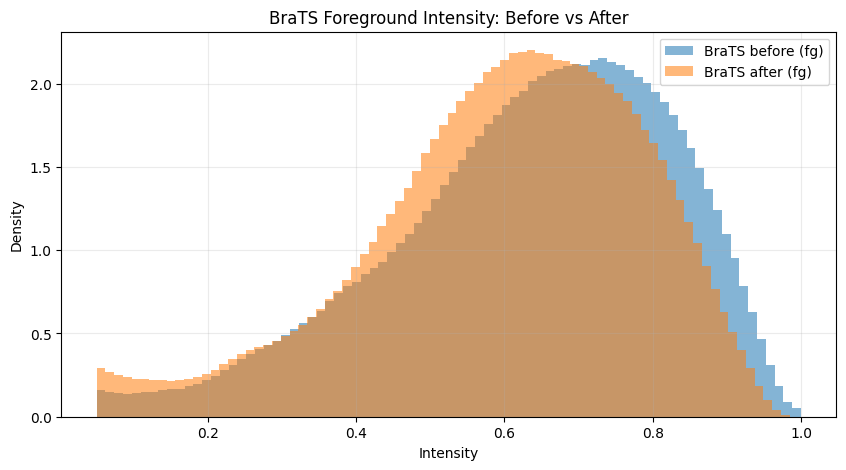

In [ ]:
plt.figure(figsize=(10, 5))
if brats_before_fg is not None and brats_before_fg.size > 0:
    plt.hist(brats_before_fg, bins=80, alpha=0.55, density=True, label='BraTS before (fg)')
if brats_after_fg is not None and brats_after_fg.size > 0:
    plt.hist(brats_after_fg, bins=80, alpha=0.55, density=True, label='BraTS after (fg)')
plt.title('BraTS Foreground Intensity: Before vs After')
plt.xlabel('Intensity')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## IXI: Before vs After

In [9]:
ixi_before_df, ixi_before_fg = summarize_files(ixi_before_files, sample_n=100)
ixi_after_df, ixi_after_fg = summarize_files(ixi_after_files, sample_n=100)

ixi_results = pd.DataFrame([
    {'Metric': 'Global mean intensity', 'Before': safe_mean(ixi_before_df, 'mean_all'), 'After': safe_mean(ixi_after_df, 'mean_all')},
    {'Metric': 'Global std intensity', 'Before': safe_mean(ixi_before_df, 'std_all'), 'After': safe_mean(ixi_after_df, 'std_all')},
    {'Metric': 'Foreground ratio', 'Before': safe_mean(ixi_before_df, 'fg_ratio'), 'After': safe_mean(ixi_after_df, 'fg_ratio')},
    {'Metric': 'Background mean', 'Before': safe_mean(ixi_before_df, 'bg_mean'), 'After': safe_mean(ixi_after_df, 'bg_mean')},
    {'Metric': 'Background std', 'Before': safe_mean(ixi_before_df, 'bg_std'), 'After': safe_mean(ixi_after_df, 'bg_std')},
    {'Metric': 'Center offset (pixels)', 'Before': safe_mean(ixi_before_df, 'center_offset_px'), 'After': safe_mean(ixi_after_df, 'center_offset_px')}
])
ixi_results['Delta (After-Before)'] = ixi_results['After'] - ixi_results['Before']
ixi_results

,Metric,Before,After,Delta (After-Before)
0,Global mean intensity,0.105817,0.211530,0.105713
1,Global std intensity,0.201967,0.330133,0.128166
2,Foreground ratio,0.241935,0.331771,0.089835
3,Background mean,0.000011,0.000878,0.000867
4,Background std,0.000557,0.003769,0.003211
5,Center offset (pixels),26.888274,0.310520,-26.577754


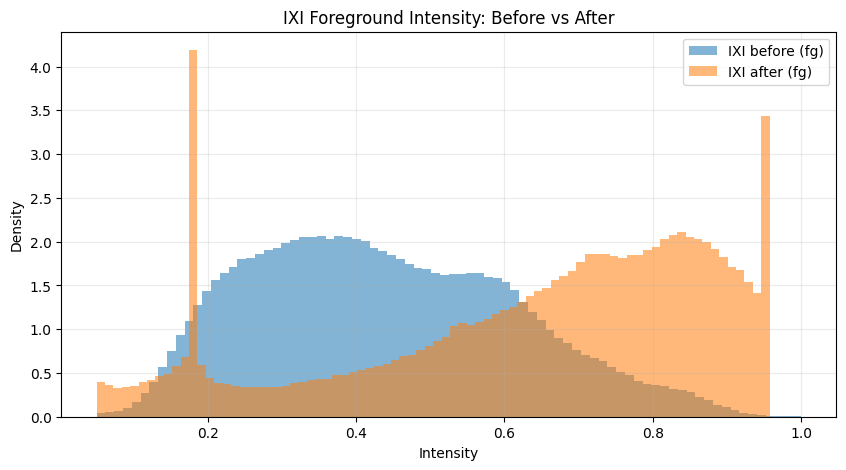

In [10]:
plt.figure(figsize=(10, 5))
if ixi_before_fg is not None and ixi_before_fg.size > 0:
    plt.hist(ixi_before_fg, bins=80, alpha=0.55, density=True, label='IXI before (fg)')
if ixi_after_fg is not None and ixi_after_fg.size > 0:
    plt.hist(ixi_after_fg, bins=80, alpha=0.55, density=True, label='IXI after (fg)')
plt.title('IXI Foreground Intensity: Before vs After')
plt.xlabel('Intensity')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

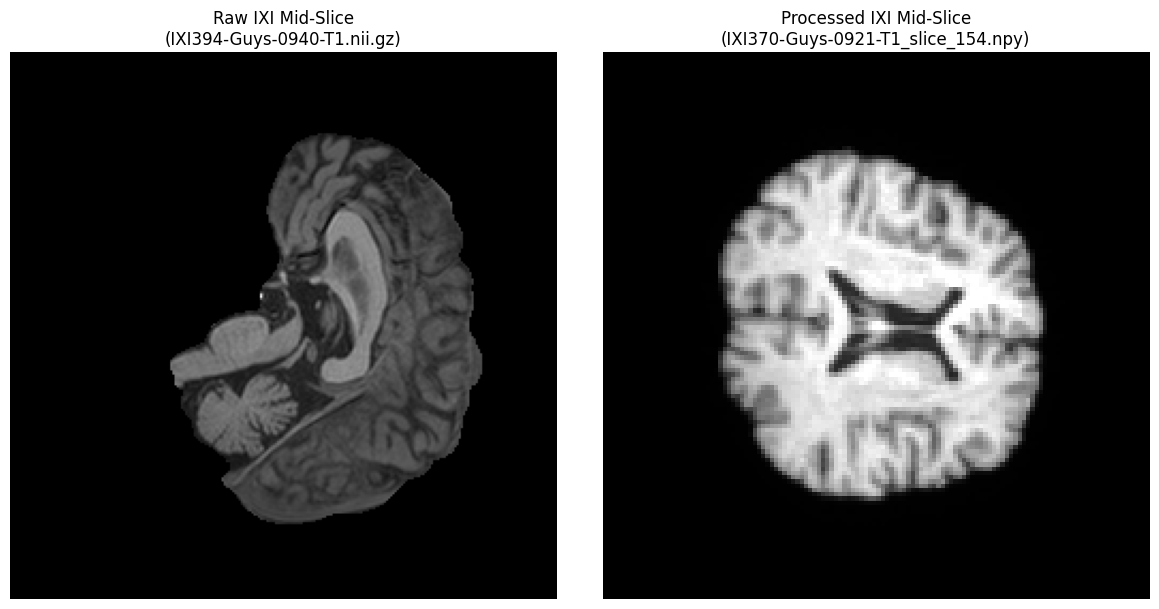

In [62]:
if ixi_before_files:
    random_ixi_before_file = random.choice(ixi_before_files)
    ixi_before_slice = load_slice(random_ixi_before_file)
else:
    random_ixi_before_file = 'N/A'
    ixi_before_slice = None

if ixi_after_files:
    random_ixi_after_file = random.choice(ixi_after_files)
    ixi_after_slice = load_slice(random_ixi_after_file)
else:
    random_ixi_after_file = 'N/A'
    ixi_after_slice = None

plt.figure(figsize=(12, 6))

if ixi_before_slice is not None:
    plt.subplot(1, 2, 1)
    plt.imshow(ixi_before_slice, cmap='gray')
    plt.title(f'Raw IXI Mid-Slice\n({os.path.basename(random_ixi_before_file)})')
    plt.axis('off')
else:
    plt.subplot(1, 2, 1)
    plt.text(0.5, 0.5, 'No raw IXI files found', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    plt.axis('off')

if ixi_after_slice is not None:
    plt.subplot(1, 2, 2)
    plt.imshow(ixi_after_slice, cmap='gray')
    plt.title(f'Processed IXI Mid-Slice\n({os.path.basename(random_ixi_after_file)})')
    plt.axis('off')
else:
    plt.subplot(1, 2, 2)
    plt.text(0.5, 0.5, 'No processed IXI files found', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    plt.axis('off')

plt.tight_layout()
plt.show()

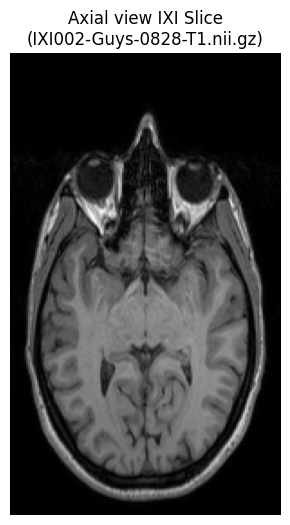

In [70]:
if IXI_RAW_UNSTRIPPED and raw_ixi_files:
    random_raw_ixi_nii_file = None
    for f in raw_ixi_files:
        if f.lower().endswith('.nii') or f.lower().endswith('.nii.gz'):
            random_raw_ixi_nii_file = f
            break

    if random_raw_ixi_nii_file:
        # Load a coronal slice (axis=1)
        coronal_ixi_slice = load_nii_slice_from_axis(random_raw_ixi_nii_file, axis=1)

        plt.figure(figsize=(6, 6))
        plt.imshow(coronal_ixi_slice, cmap='gray')
        plt.title(f'Axial view IXI Slice\n({os.path.basename(random_raw_ixi_nii_file)})')
        plt.axis('off')
        plt.show()
    else:
        print('No NIfTI files found in raw IXI data directory.')
else:
    print('Raw IXI data directory not found or no files in specified paths.')